In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import geopandas as gpd

# Quanto se poupou com a instalação de sistemas de autoconsumo ?

# Correlação entre o consumo mensal por distrito e o nº de instalações

In [ ]:
# Carregar os dados de consumos mensais
dados_consumos = pd.read_csv('./data/consumos-mensais-por-distrito.csv', sep=';')

# Converter a coluna 'Data' para o formato datetime
dados_consumos['Data'] = pd.to_datetime(dados_consumos['Data'], errors='coerce')

# Criar a coluna 'Ano' a partir da coluna 'Data'
dados_consumos['Ano'] = dados_consumos['Data'].dt.year

# Filtrar os dados para os anos de 2022 a 2025 a partir de abril de 2022
dados_consumos_filtrados = dados_consumos[(dados_consumos['Ano'].between(2022, 2025)) & (dados_consumos['mes_int'] >= 4)]

# Criar uma nova coluna para definir os trimestres personalizados
def definir_trimestre(ano, mes):
    if mes in [4, 5, 6]:
        return f"{ano}T2"  # Segundo trimestre do respectivo ano
    elif mes in [7, 8, 9]:
        return f"{ano}T3"  # Terceiro trimestre do respectivo ano
    elif mes in [10, 11, 12]:
        return f"{ano}T4"  # Quarto trimestre do respectivo ano
    elif mes in [1, 2, 3]:
        return f"{ano}T1"  # Primeiro trimestre (caso tenha dados)
    else:
        return None  # Não deveria haver outros meses

dados_consumos_filtrados['Trimestre'] = dados_consumos_filtrados.apply(lambda x: definir_trimestre(x['Ano'], x['mes_int']), axis=1)

# Agrupar os dados por Trimestre e somar a Energia Ativa (kWh)
tabela_trimestral = dados_consumos_filtrados.groupby('Trimestre')['Energia Ativa (kWh)'].sum().reset_index()

# Exibir a tabela resultante
print(tabela_trimestral)


  Trimestre  Energia Ativa (kWh)
0    2022T2         1.109251e+10
1    2022T3         1.137552e+10
2    2022T4         1.143033e+10
3    2023T2         1.089110e+10
4    2023T3         1.127725e+10
5    2023T4         1.179387e+10
6    2024T2         1.100252e+10
7    2024T3         1.141486e+10
8    2024T4         7.606554e+09


C:\Users\User\AppData\Local\Temp\ipykernel_16292\2602175813.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_consumos_filtrados['Trimestre'] = dados_consumos_filtrados.apply(lambda x: definir_trimestre(x['Ano'], x['Mês']), axis=1)


In [3]:
# Carregar os dados do autoconsumo
dados_autoconsumo = pd.read_csv('./data/e-redes_autoconsumo.csv', sep=';')

# Gerar a lista de trimestres para os anos 2022 a 2025
trimestres_desejados = [f"{ano}T{t}" for ano in range(2022, 2026) for t in range(1, 5)]

# Filtrar apenas os dados dos trimestres desejados
dados_filtrados = dados_autoconsumo[dados_autoconsumo['Trimestre'].isin(trimestres_desejados)]

# Selecionar apenas as colunas relevantes (opcional)
dados_filtrados = dados_filtrados[['Trimestre', 'Distrito', 'Número de instalacões']]

# Exibir os dados filtrados
print(dados_filtrados.head())

  Trimestre  Distrito  Número de instalacões
0    2023T3  Santarém                      2
1    2023T3  Santarém                      1
2    2023T3  Santarém                      6
3    2023T3  Santarém                      1
4    2023T3  Santarém                      1


C:\Users\User\AppData\Local\Temp\ipykernel_16292\4237448309.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(tabela_global['Trimestre'], rotation=45)  # Rotação para melhor visualização


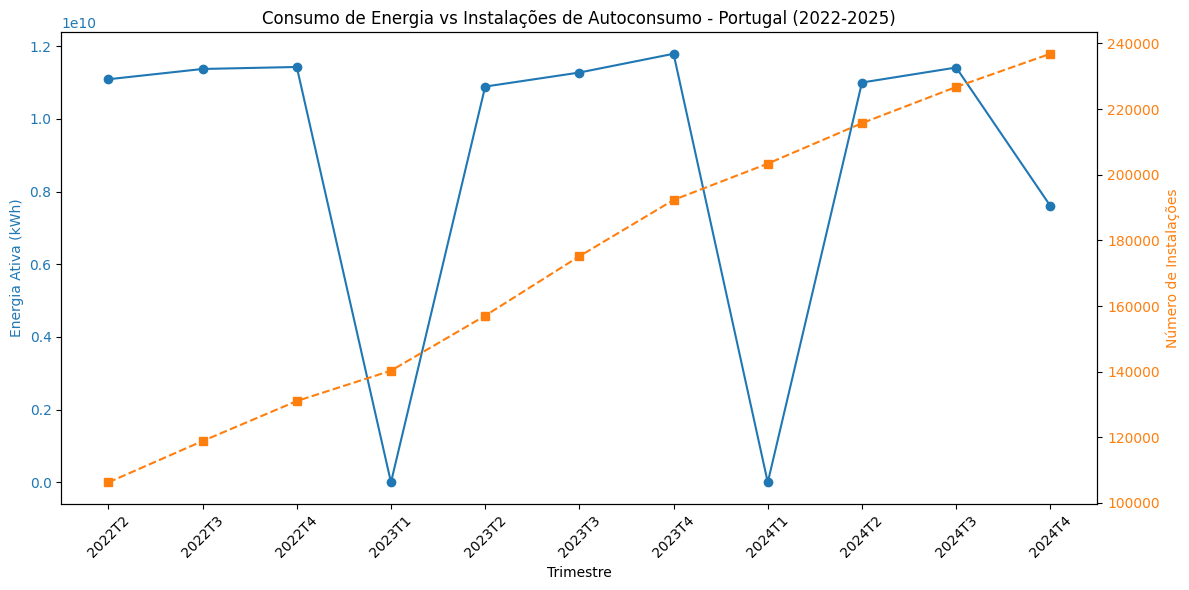

In [8]:
# Combinar os dados globais (Consumo e Instalações)
tabela_global = pd.merge(tabela_trimestral, dados_filtrados.groupby('Trimestre')['Número de instalacões'].sum().reset_index(), on='Trimestre', how='outer').fillna(0)

# Ordenar a tabela global pelos trimestres corretamente
tabela_global = tabela_global.sort_values(by="Trimestre")

# Criar o gráfico
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot do consumo global
ax1.set_xlabel('Trimestre')
ax1.set_ylabel('Energia Ativa (kWh)', color='tab:blue')
ax1.plot(tabela_global['Trimestre'], tabela_global['Energia Ativa (kWh)'], marker='o', linestyle='-', color='tab:blue', label='Consumo de Energia')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticklabels(tabela_global['Trimestre'], rotation=45)  # Rotação para melhor visualização

# Criar um segundo eixo Y para instalações
ax2 = ax1.twinx()
ax2.set_ylabel('Número de Instalações', color='tab:orange')
ax2.plot(tabela_global['Trimestre'], tabela_global['Número de instalacões'], marker='s', linestyle='--', color='tab:orange', label='Instalações de Autoconsumo')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Adicionar título e legenda
plt.title('Consumo de Energia vs Instalações de Autoconsumo - Portugal (2022-2025)')
fig.tight_layout()
plt.show()


In [ ]:
# Certificar que os dados estão ordenados corretamente
tabela_global = tabela_global.sort_values(by="Trimestre")

# Calcular o coeficiente de correlação de Pearson
correlacao, p_valor = pearsonr(tabela_global['Energia Ativa (kWh)'], tabela_global['Número de instalacões'])

# Exibir os resultados
print(f"Coeficiente de Correlação de Pearson: {correlacao:.4f}")
print(f"Valor-p: {p_valor:.4f}")

# Interpretar a correlação
if correlacao > 0.7:
    interpretacao = "Correlação forte positiva"
elif correlacao > 0.4:
    interpretacao = "Correlação moderada positiva"
elif correlacao > 0.1:
    interpretacao = "Correlação fraca positiva"
elif correlacao < -0.1:
    interpretacao = "Correlação fraca negativa"
elif correlacao < -0.4:
    interpretacao = "Correlação moderada negativa"
elif correlacao < -0.7:
    interpretacao = "Correlação forte negativa"
else:
    interpretacao = "Sem correlação significativa"

print(f"Interpretação: {interpretacao}")


Coeficiente de Correlação de Pearson: -0.0943
Valor-p: 0.7826
Interpretação: Sem correlação significativa


# Consumos mensais por distrito (Evolução)

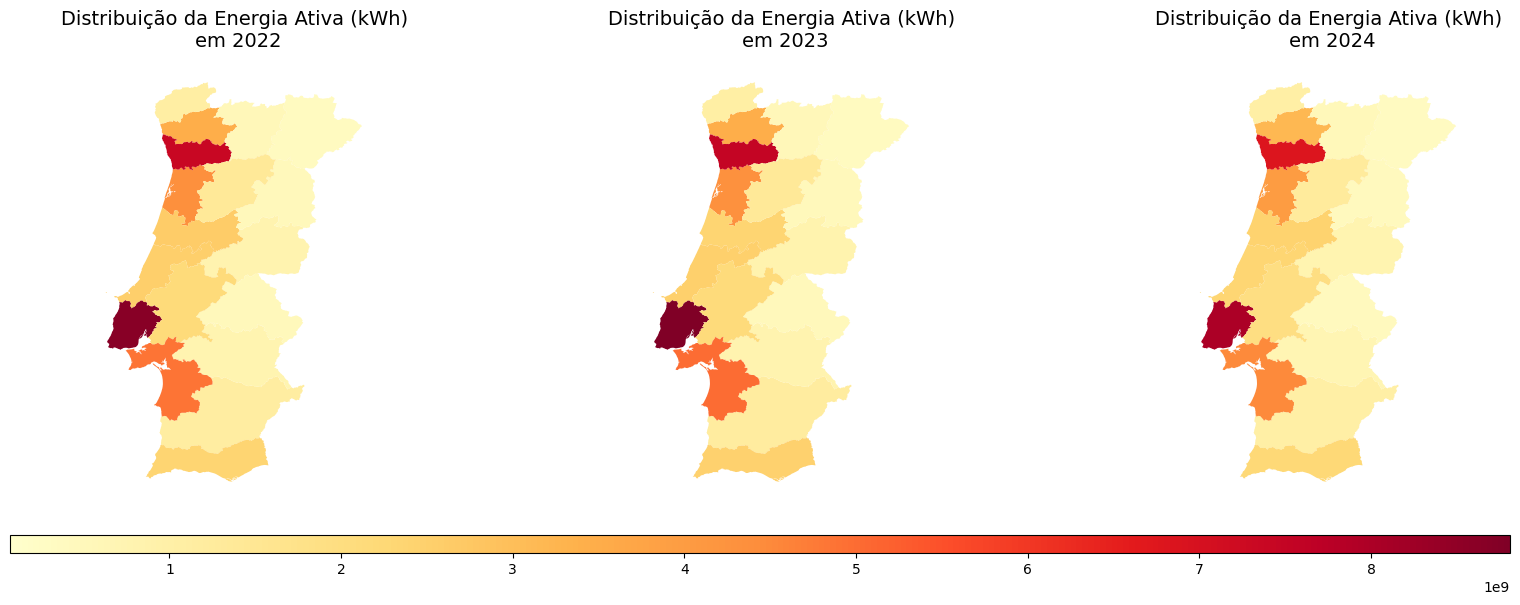

In [ ]:
# Carregar os dados de consumo mensal
dados_consumos = pd.read_csv('./data/consumos-mensais-por-distrito.csv', sep=';')

# Converter a coluna 'Data' para o formato datetime
dados_consumos['Data'] = pd.to_datetime(dados_consumos['Data'], errors='coerce')

# Criar a coluna 'Ano' a partir da coluna 'Data'
dados_consumos['Ano'] = dados_consumos['Data'].dt.year

# Agrupar os dados por 'Distrito' e 'Ano', somando a 'Energia Ativa (kWh)'
tabela_consumo = dados_consumos.groupby(['Distrito', 'Ano'])['Energia Ativa (kWh)'].sum().reset_index()

# Carregar o shapefile de Portugal (ajustar o caminho conforme necessário)
mapa_pt = gpd.read_file('./pt.json')

# Se o nome da coluna no shapefile não for 'Distrito', renomeie para 'Distrito'
if 'NAME_1' in mapa_pt.columns:
    mapa_pt = mapa_pt.rename(columns={'NAME_1': 'Distrito'})

# Calcular o valor mínimo e máximo para a energia ativa em todos os anos
min_value = tabela_consumo['Energia Ativa (kWh)'].min()
max_value = tabela_consumo['Energia Ativa (kWh)'].max()

# Função para gerar os mapas por ano
def plot_map_for_year(year, ax, norm, cmap):
    # Filtrar os dados para o ano desejado
    df_ano = tabela_consumo[tabela_consumo['Ano'] == year]
    
    # Unir o DataFrame de consumo com o shapefile com base no distrito
    mapa_ano = mapa_pt.merge(df_ano, on='Distrito', how='left')

    # Calcular as cores usando a normalização
    colors = [cmap(norm(val)) for val in mapa_ano['Energia Ativa (kWh)']]

    # Plotar o mapa com o gradiente de cores
    mapa_ano.plot(color=colors, legend=False, ax=ax)
    
    # Adicionar título
    ax.set_title(f"Distribuição da Energia Ativa (kWh) \nem {year}", fontsize=14)
    ax.set_axis_off()  # Ocultar os eixos para um mapa mais limpo
    
    # Ajuste manual dos limites para remover o espaço em branco
    ax.set_xlim([-9.6, -6])  # Limites ajustados para focar em Portugal continental
    ax.set_ylim([36.5, 42.5])  # Limites ajustados para focar em Portugal continental
    ax.set_aspect('equal')  # Manter proporção correta do mapa

# Criar a figura com 3 subgráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Normalização da escala para todos os mapas
norm = mpl.colors.Normalize(vmin=min_value, vmax=max_value)
cmap = mpl.cm.YlOrRd

# Gerar os mapas para os anos de 2022, 2023 e 2024
plot_map_for_year(2022, axes[0], norm, cmap)
plot_map_for_year(2023, axes[1], norm, cmap)
plot_map_for_year(2024, axes[2], norm, cmap)

# Criar a barra de cores (legend) manualmente abaixo dos mapas
cbar_ax = fig.add_axes([0.125, 0.05, 0.75, 0.03])  # Posição da barra de cores (ajustando a posição para ficar abaixo)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Nenhuma entrada real para a barra de cores
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')

# Ajustar o layout manualmente para evitar sobreposição e colocar a barra de cores
plt.subplots_adjust(hspace=0.3)  # Ajuste do espaçamento entre os gráficos e a barra de cores

# Exibir os mapas lado a lado com a barra de cores abaixo
plt.show()


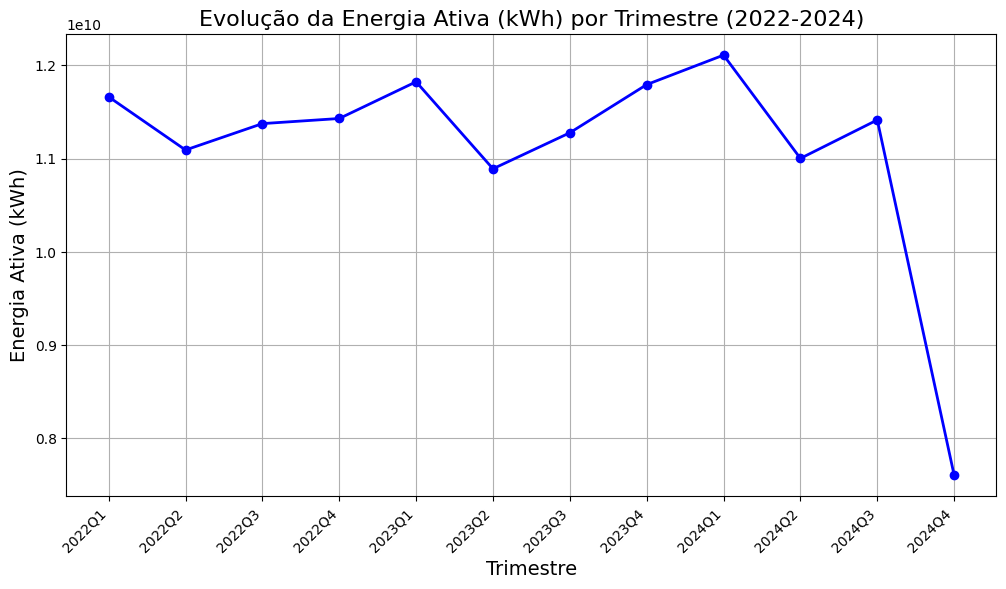

In [ ]:
# Carregar o arquivo CSV com o separador correto
dados = pd.read_csv('./data/consumos-mensais-por-distrito.csv', sep=';')

# Converter a coluna 'Data' para o formato datetime
dados['Data'] = pd.to_datetime(dados['Data'], errors='coerce')

# Criar a coluna 'Trimestre' a partir da coluna 'Data' (usando o método anterior para definir o trimestre)
dados['Trimestre'] = dados['Data'].dt.to_period('Q')

# Agrupar os dados por 'Trimestre', somando a 'Energia Ativa (kWh)'
tabela_energia_trimestre = dados.groupby('Trimestre')['Energia Ativa (kWh)'].sum().reset_index()

# Filtrar os últimos 3 anos (2022, 2023, 2024)
tabela_energia_trimestre = tabela_energia_trimestre[tabela_energia_trimestre['Trimestre'].dt.year.isin([2022, 2023, 2024])]

# Ordenar os trimestres corretamente
tabela_energia_trimestre = tabela_energia_trimestre.sort_values(by='Trimestre')

# Plotar o gráfico de evolução da energia ativa por trimestre
plt.figure(figsize=(12, 6))
plt.plot(tabela_energia_trimestre['Trimestre'].astype(str), tabela_energia_trimestre['Energia Ativa (kWh)'], marker='o', color='b', linestyle='-', linewidth=2)

# Melhorar a legibilidade do eixo X
plt.xticks(rotation=45, ha='right')

# Adicionar título e rótulos aos eixos
plt.title('Evolução da Energia Ativa (kWh) por Trimestre (2022-2024)', fontsize=16)
plt.xlabel('Trimestre', fontsize=14)
plt.ylabel('Energia Ativa (kWh)', fontsize=14)
plt.grid(True)

# Exibir o gráfico
plt.show()
